# Project 3: Semantic Segmentation

This project evaluates your understanding and implementation of a semantic segmentation pipeline. The overall project is divided into several sections, with specific marks assigned to each.


**Mark Distribution**:

<div align = "center">
    <table>
        <tr><td><h3>No.</h3></td> <td><h3>Section</h3></td> <td><h3>Points</h3></td> </tr>
        <tr><td><h3>1.1.</h3></td> <td><h3> Dataset Class</h3></td> <td><h3>15</h3></td> </tr>
        <tr><td><h3>1.2</h3></td> <td><h3> Visualize dataset</h3></td> <td><h3>10</h3></td> </tr>
        <tr><td><h3>2.</h3></td> <td><h3>  Define Evaluation Metrics</h3></td> <td><h3>10</h3></td> </tr>
        <tr><td><h3>3.</h3></td> <td><h3>  Model Definition</h3></td> <td><h3>10</h3></td> </tr>
        <tr><td><h3>4.</h3></td> <td><h3>  Train</h3></td> <td><h3>15</h3></td> </tr>
        <tr><td><h3>5.</h3></td> <td><h3>  Inference</h3></td> <td><h3>10</h3></td> </tr>
        <tr><td><h3>6.</h3></td> <td><h3> mIoU Score</h3></td> <td><h3>30</h3></td> </tr>
    </table>
        
</div>

---

Breakdown of mIoU Score on Test Dataset **(30 Points)**:

The mIoU Score section evaluates the quality of your segmentation model. Points are awarded based on the achieved mIoU (Mean Intersection over Union) score on the test dataset, as shown below:

<div align="center">
    <table>
        <tr><td><h3>No.</h3></td> <td><h3>mIoU Score Range</h3></td> <td><h3>Points</h3></td> </tr>
        <tr><td><h3>1.</h3></td> <td><h3>>=65% and < 70%</h3></td> <td><h3>10</h3></td> </tr>
        <tr><td><h3>2.</h3></td> <td><h3>>= 70% and < 73%</h3></td> <td><h3>20</h3></td> </tr>
        <tr><td><h3>3.</h3></td> <td><h3>>= 73%</h3></td><td><h3>30</h3></td> </tr>
    </table>
</div>


<h2 style = "color: green;">1. Data Exploration </h2>

In this section, you have to write your custom dataset class and visualize a few images (minimum five images) along with their mask overlayed.

<h2 style = "color: green;">1.1. Dataset Class [15 Points]</h2>

**In this sub-section, write your custom dataset class.**

**For example:**

```python
class SemSegDataset(Dataset):
    """ Generic Dataset class for semantic segmentation datasets.

        Arguments:
            train_image: path to input train images
            train_mask: path to input train mask labels
            train_tfms: transformations (if any)
            label_colors_list: mapping of label value to color code
            classes_to_train: number of classes

            Names of images in the images_folder and masks_folder should be the same for the same samples.
    """
```

For this Semantic Segmentation Project, you will be working on the **[ICPR Retinal Blood Vessels Dataset](https://www.dropbox.com/scl/fi/tscgh3pxwzfvesnu6l6uv/icpr_prepared.zip?rlkey=8oay8sod3jc1hvwhgqvylaefr&st=udj92wmp&dl=1).**

In [1]:
import os
import zipfile
import requests

In [2]:
def download_and_unzip(url, save_path):

    print("Downloading and extracting assets...", end="")
    file = requests.get(url)
    open(save_path, "wb").write(file.content)

    try:
        with zipfile.ZipFile(save_path) as z:
            z.extractall(os.path.split(save_path)[0]) 
            print("Done")
    except:
        print("Invalid file")

In [3]:
URL = r""  

dataset_path = "./icpr_prepared"

train_images_path = os.path.join(dataset_path, "train_images")
train_masks_path  = os.path.join(dataset_path, "train_labels")
test_images_path  = os.path.join(dataset_path, "test_images")
test_masks_path   = os.path.join(dataset_path, "test_labels")

required = {
    "train_images": train_images_path,
    "train_labels": train_masks_path,
    "test_images": test_images_path,
    "test_labels": test_masks_path,
}

for name, p in required.items():
    print(name, "->", p, "EXISTS?", os.path.exists(p))


train_images -> ./icpr_prepared/train_images EXISTS? True
train_labels -> ./icpr_prepared/train_labels EXISTS? True
test_images -> ./icpr_prepared/test_images EXISTS? True
test_labels -> ./icpr_prepared/test_labels EXISTS? True


In [4]:
import random
from pathlib import Path
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
from PIL import Image

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')



Using device: cuda


In [5]:
import os

print("Searching for icpr_prepared...")
for root, dirs, files in os.walk(".", topdown=True):
    if "icpr_prepared" in dirs:
        print("[FOUND] Dataset at:", os.path.join(root, "icpr_prepared"))
        break
else:
    print("[ERROR] Could not find icpr_prepared anywhere under this project folder.")


Searching for icpr_prepared...
[FOUND] Dataset at: ./icpr_prepared


In [6]:
IMG_EXTS = ('.tif', '.tiff')

def _find_mask_from_image_name(img_name: str, masks_dir: str):
    base = Path(img_name).stem
    for suffix in ['', '_mask', '_manual1', '_label']:
        for ext in IMG_EXTS:
            candidate = Path(masks_dir) / f"{base}{suffix}{ext}"
            if candidate.exists():
                return candidate
    return None

def gather_image_mask_pairs(images_dir: str, masks_dir: str = None):
    images_dir = Path(images_dir)
    samples = []
    if not images_dir.exists():
        return samples
    image_paths = sorted([p for p in images_dir.iterdir() if p.suffix.lower() in IMG_EXTS])
    for img in image_paths:
        mask_path = None
        if masks_dir is not None and Path(masks_dir).exists():
            mask_path = _find_mask_from_image_name(img.name, masks_dir)
        samples.append((img, mask_path))
    return samples

def basic_seg_transform(resize=None, augment: bool = False):
    def _transform(image, mask=None):
        if resize is not None:
            image = TF.resize(image, resize)
            if mask is not None:
                mask = TF.resize(mask, resize, interpolation=Image.NEAREST)
        if augment:
            if random.random() > 0.5:
                image = TF.hflip(image)
                if mask is not None:
                    mask = TF.hflip(mask)
            if random.random() > 0.5:
                image = TF.vflip(image)
                if mask is not None:
                    mask = TF.vflip(mask)
        image_t = TF.to_tensor(image)
        mask_t = None
        if mask is not None:
            mask_np = np.array(mask, dtype=np.int64)
            if mask_np.max() > 1:
                mask_np = (mask_np > 0).astype(np.int64)
            mask_t = torch.from_numpy(mask_np).long()
        return image_t, mask_t
    return _transform

class SemSegDataset(Dataset):
    """Generic Dataset class for semantic segmentation datasets."""
    def __init__(self, images_dir: str, masks_dir: str = None, transform=None, file_pairs=None, num_classes: int = 2):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform = transform
        self.num_classes = num_classes
        self.samples = file_pairs if file_pairs is not None else gather_image_mask_pairs(images_dir, masks_dir)
        if len(self.samples) == 0:
            print(f"[Warning] No samples found in {images_dir}. Please ensure the dataset is available.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, mask_path = self.samples[idx]
        image = Image.open(image_path).convert('RGB')
        mask = None
        if mask_path is not None and Path(mask_path).exists():
            mask = Image.open(mask_path).convert('L')

        if self.transform is not None:
            image, mask = self.transform(image, mask)
        else:
            image = TF.to_tensor(image)
            if mask is not None:
                mask = torch.from_numpy(np.array(mask, dtype=np.int64))

        if mask is None:
            mask = torch.zeros((image.shape[1], image.shape[2]), dtype=torch.long)
        else:
            if mask.dtype != torch.long:
                mask = mask.long()
            if mask.max() > 1:
                mask = (mask > 0).long()
        return image, mask

def overlay_mask_on_image(image_tensor, mask_tensor, alpha: float = 0.5, color=(1.0, 0.0, 0.0)):
    image_np = image_tensor.permute(1, 2, 0).cpu().numpy()
    mask_np = mask_tensor.cpu().numpy()
    if mask_np.max() > 1:
        mask_np = (mask_np > 0).astype(float)
    mask_np = np.clip(mask_np, 0, 1)
    overlay = image_np.copy()
    overlay[mask_np > 0] = (1 - alpha) * overlay[mask_np > 0] + alpha * np.array(color)
    return overlay



In [7]:
image_size = (256, 256)
batch_size = 4
num_classes = 2


train_images_dir = os.path.join(dataset_path, "train_images")
train_masks_dir  = os.path.join(dataset_path, "train_labels")
test_images_dir  = os.path.join(dataset_path, "test_images")
test_masks_dir   = os.path.join(dataset_path, "test_labels")

val_images_dir = None
val_masks_dir  = None

required_dirs = {
    "train_images_dir": train_images_dir,
    "train_masks_dir":  train_masks_dir,
    "test_images_dir":  test_images_dir,
    "test_masks_dir":   test_masks_dir,
}

for name, p in required_dirs.items():
    if not os.path.isdir(p):
        raise FileNotFoundError(f"{name} not found at: {p}")

print("[INFO] Using real ICPR dataset folders:")
for name, p in required_dirs.items():
    print(f" - {name}: {p}")

train_pairs = gather_image_mask_pairs(train_images_dir, train_masks_dir)


val_pairs = []
test_pairs = gather_image_mask_pairs(test_images_dir, test_masks_dir)

train_transform = basic_seg_transform(resize=image_size, augment=True)
val_transform   = basic_seg_transform(resize=image_size, augment=False)

if len(val_pairs) == 0 and len(train_pairs) > 1:
    random.shuffle(train_pairs)
    split_idx = int(0.8 * len(train_pairs))
    val_pairs = train_pairs[split_idx:]
    train_pairs = train_pairs[:split_idx]

if len(train_pairs) == 0:
    raise RuntimeError(
        f"No training pairs found in:\n"
        f"  images: {train_images_dir}\n"
        f"  masks:  {train_masks_dir}\n"
        f"Check filenames and extensions."
    )

train_dataset = SemSegDataset(
    train_images_dir,
    train_masks_dir,
    transform=train_transform,
    file_pairs=train_pairs,
    num_classes=num_classes,
)

val_dataset = SemSegDataset(
    train_images_dir if val_images_dir is None else val_images_dir,
    train_masks_dir if val_masks_dir is None else val_masks_dir,
    transform=val_transform,
    file_pairs=val_pairs if len(val_pairs) else None,
    num_classes=num_classes,
)

test_dataset = SemSegDataset(
    test_images_dir,
    test_masks_dir,
    transform=val_transform,
    file_pairs=test_pairs if len(test_pairs) else None,
    num_classes=num_classes,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=1,          shuffle=False, num_workers=2, pin_memory=True)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")


[INFO] Using real ICPR dataset folders:
 - train_images_dir: ./icpr_prepared/train_images
 - train_masks_dir: ./icpr_prepared/train_labels
 - test_images_dir: ./icpr_prepared/test_images
 - test_masks_dir: ./icpr_prepared/test_labels
Train samples: 110, Val samples: 28, Test samples: 40


<h2 style = "color: green;">1.2. Visualize dataset [10 Points]</h2>


**In this sub-section,  you have to plot a few images and its mask.**


In [8]:
def visualize_samples(dataset, num_samples: int = 5, title_prefix: str = 'Sample'):
    to_display = min(num_samples, len(dataset))
    if to_display == 0:
        print('Dataset is empty, nothing to visualize.')
        return
    plt.figure(figsize=(14, 3 * to_display))
    for idx in range(to_display):
        image, mask = dataset[idx]
        sample_path = dataset.samples[idx][0] if hasattr(dataset, 'samples') else None
        print(sample_path)
        sample_name = Path(sample_path).name if sample_path is not None else f'sample_{idx}'
        sample_folder = Path(sample_path).parent.name if sample_path is not None else 'unknown_folder'
        overlay = overlay_mask_on_image(image, mask)
        base_np = image.permute(1, 2, 0).numpy()
        mask_np = mask.numpy()

        plt.subplot(to_display, 3, idx * 3 + 1)
        plt.imshow(base_np)
        plt.title(f"{title_prefix} {idx+1} - Image\n{sample_name} @ {sample_folder}")
        plt.axis('off')

        plt.subplot(to_display, 3, idx * 3 + 2)
        plt.imshow(mask_np, cmap='gray')
        plt.title('Mask')
        plt.axis('off')

        plt.subplot(to_display, 3, idx * 3 + 3)
        plt.imshow(overlay)
        plt.title('Overlay')
        plt.axis('off')
    plt.tight_layout()
    plt.show()




icpr_prepared/train_images/image_12.tif
icpr_prepared/train_images/image_313.tif
icpr_prepared/train_images/image_98.tif
icpr_prepared/train_images/image_107.tif
icpr_prepared/train_images/image_93.tif


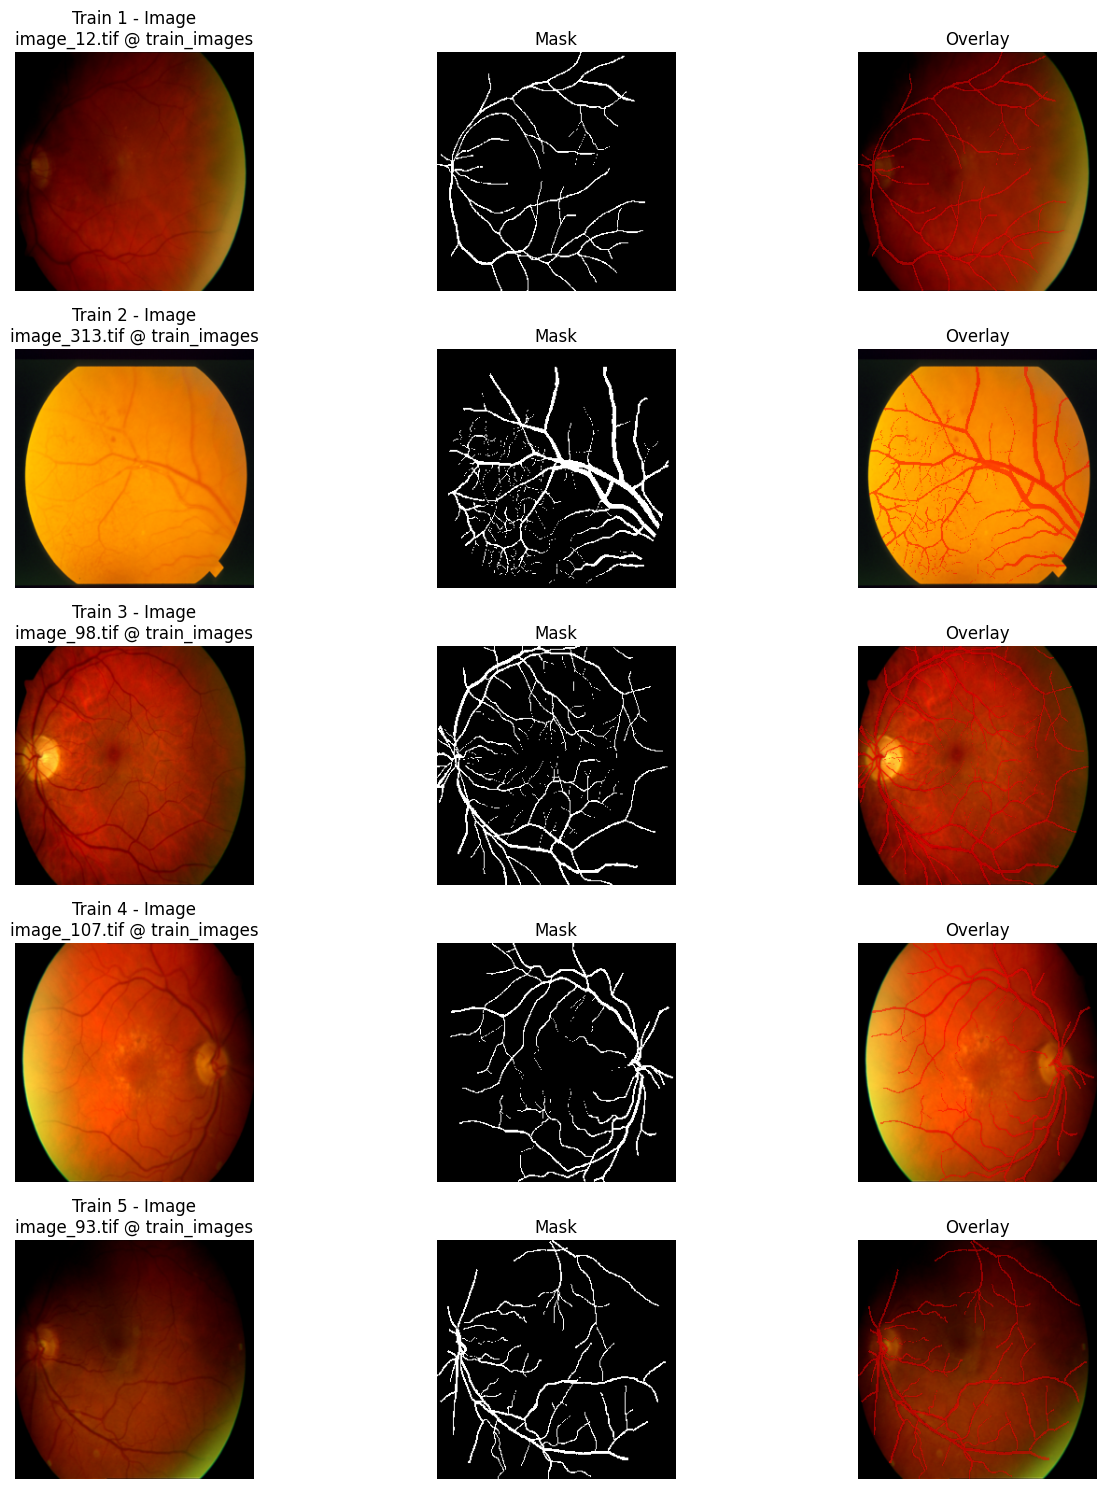

In [9]:
visualize_samples(train_dataset if len(train_dataset) > 0 else val_dataset, num_samples=5, title_prefix='Train')



icpr_prepared/train_images/image_94.tif
icpr_prepared/train_images/image_42.tif
icpr_prepared/train_images/image_95.tif


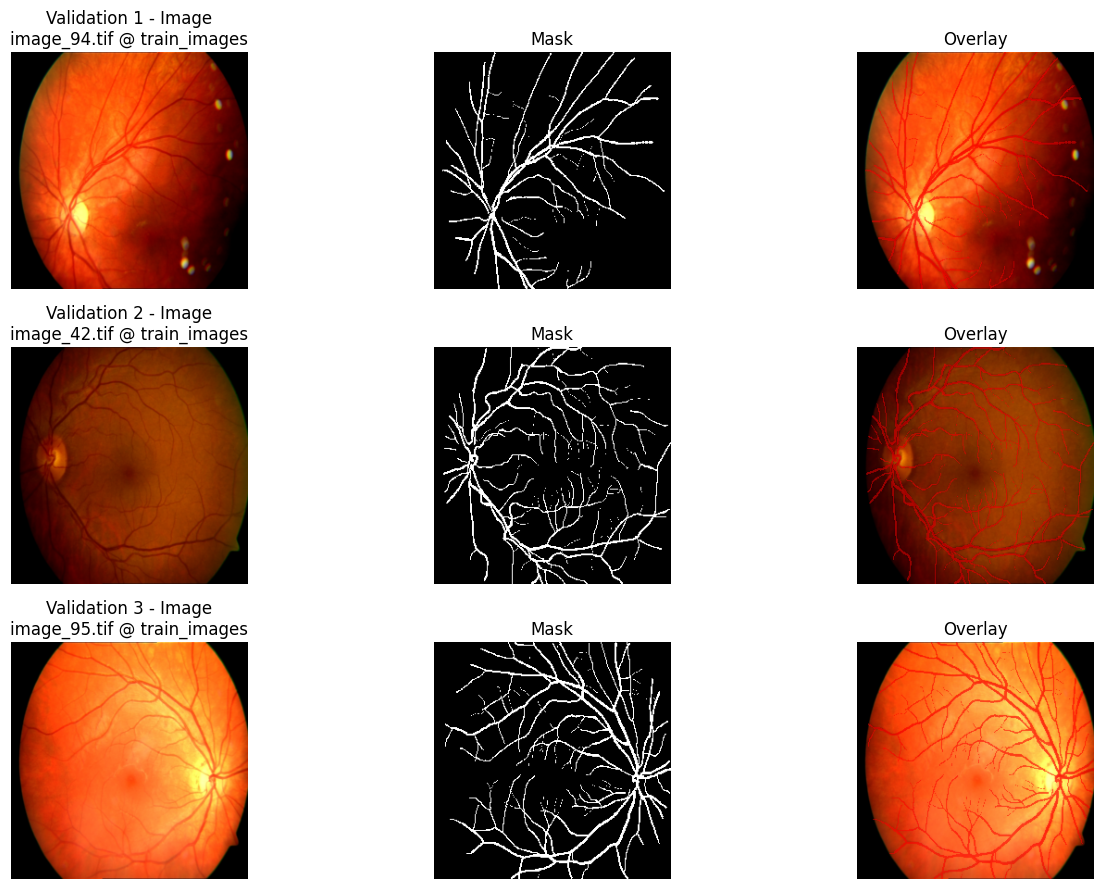

In [10]:
visualize_samples(val_dataset, num_samples=3, title_prefix='Validation')



<h2 style = "color: green;">2. Define Evaluation Metrics [10 Points]</h2>


This project is evaluated on the mean IoU

Mean Intersection over Union (mIoU) is a metric that measures the average overlap between predicted and actual objects in an image or set of images. It's calculated by averaging the Intersection over Union (IoU) of each class in an image.


**In this section, you have to implement the mIoU evaluation metric.**

In [11]:
def compute_confusion_matrix(preds: torch.Tensor, targets: torch.Tensor, num_classes: int, ignore_index: int = None):
    if preds.dim() == targets.dim() + 1:
        preds = preds.argmax(dim=1)
    preds = preds.view(-1)
    targets = targets.view(-1)
    if ignore_index is not None:
        valid = targets != ignore_index
        preds = preds[valid]
        targets = targets[valid]
    conf = torch.zeros((num_classes, num_classes), dtype=torch.float64, device=preds.device)
    k = (targets >= 0) & (targets < num_classes)
    inds = num_classes * targets[k].to(torch.int64) + preds[k]
    conf += torch.bincount(inds, minlength=num_classes ** 2).reshape(num_classes, num_classes)
    return conf

def compute_iou_per_class(conf_matrix: torch.Tensor):
    tp = conf_matrix.diag()
    fp = conf_matrix.sum(dim=0) - tp
    fn = conf_matrix.sum(dim=1) - tp
    denom = tp + fp + fn
    iou = tp / torch.clamp(denom, min=1e-6)
    return iou

def mean_iou(preds: torch.Tensor, targets: torch.Tensor, num_classes: int, ignore_index: int = None):
    conf = compute_confusion_matrix(preds, targets, num_classes=num_classes, ignore_index=ignore_index)
    iou_per_class = compute_iou_per_class(conf)
    miou = iou_per_class.mean().item()
    return miou, iou_per_class.cpu().numpy()



In [12]:
def pixel_accuracy(preds: torch.Tensor, targets: torch.Tensor):
    if preds.dim() == targets.dim() + 1:
        preds = preds.argmax(dim=1)
    correct = (preds == targets).float().sum()
    total = torch.numel(targets)
    return (correct / max(total, 1)).item()



In [13]:
def evaluate_model(model, loader, criterion, device, num_classes: int):
    model.eval()
    total_loss, total_acc, total_miou = 0.0, 0.0, 0.0
    total_batches = 0
    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)
            logits = model(images)
            loss = criterion(logits, masks)
            total_loss += loss.item()
            total_acc += pixel_accuracy(logits, masks)
            miou, _ = mean_iou(logits, masks, num_classes=num_classes)
            total_miou += miou
            total_batches += 1
    if total_batches == 0:
        return 0.0, 0.0, 0.0
    return total_loss / total_batches, total_acc / total_batches, total_miou / total_batches



<h2 style = "color: green;">3. Model [10 Points]</h2>

**In this section, you have to define your model.**

In [14]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels),
        )

    def forward(self, x):
        return self.net(x)

class Up(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels)
        else:
            self.up = nn.ConvTranspose2d(in_channels // 2, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # pad if needed
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = nn.functional.pad(
            x1,
            [diffX // 2, diffX - diffX // 2,
             diffY // 2, diffY - diffY // 2],
        )
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=2, bilinear=True):
        super().__init__()
        # base channels bumped to 64
        self.inc   = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 512)

        factor = 2 if bilinear else 1
        self.up1  = Up(512 + 512, 256 // factor, bilinear)
        self.up2  = Up(256 + 256 // factor, 128 // factor, bilinear)
        self.up3  = Up(128 + 128 // factor, 64 // factor, bilinear)
        self.up4  = Up(64 + 64 // factor, 64, bilinear)
        self.outc = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x,  x3)
        x = self.up3(x,  x2)
        x = self.up4(x,  x1)
        return self.outc(x)


In [15]:
model = UNet(n_channels=3, n_classes=num_classes).to(device)
print(model)



UNet(
  (inc): DoubleConv(
    (net): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (net): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (net): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, trac

In [16]:
with torch.no_grad():
    dummy = torch.randn(1, 3, image_size[0], image_size[1]).to(device)
    out = model(dummy)
    print('Output shape:', out.shape)



Output shape: torch.Size([1, 2, 256, 256])


<h2 style = "color: green;">4. Train & Inference</h2>

- **In this section, you have to train the model and infer on sample data.**


- **You can write your trainer class in this section.**


- **If you are using any loss function other than PyTorch standard loss function, you have to define in this section.**


- **This section should also have optimizer and LR-schedular (if using) details.**

<h2 style = "color: green;">4.1. Train [15 Points]</h2>


**Write your training code in this section.**


**This section must contain training plots (use matplotlib or share tensorboard scalars logs).**

**You must have to plot the following:**
- **train loss and validation loss**


- **train accuracy and validation accuracy**


- **Mean Intersection over Union (mIoU) of these classes on validation data.**





In [17]:
def train_one_epoch(model, loader, optimizer, criterion, device, num_classes: int):
    model.train()
    running_loss, running_acc, running_miou = 0.0, 0.0, 0.0
    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_acc += pixel_accuracy(logits, masks)
        miou, _ = mean_iou(logits, masks, num_classes=num_classes)
        running_miou += miou
    num_batches = max(1, len(loader))
    return running_loss / num_batches, running_acc / num_batches, running_miou / num_batches



Epoch [1/50] - Train Loss: 0.4542, Val Loss: 0.3450, Val mIoU: 0.4603
Epoch [2/50] - Train Loss: 0.2807, Val Loss: 0.2585, Val mIoU: 0.4710
Epoch [3/50] - Train Loss: 0.2176, Val Loss: 0.2047, Val mIoU: 0.5471
Epoch [4/50] - Train Loss: 0.1840, Val Loss: 0.1879, Val mIoU: 0.5945
Epoch [5/50] - Train Loss: 0.1704, Val Loss: 0.1807, Val mIoU: 0.6037
Epoch [6/50] - Train Loss: 0.1633, Val Loss: 0.1592, Val mIoU: 0.6736
Epoch [7/50] - Train Loss: 0.1547, Val Loss: 0.1579, Val mIoU: 0.6541
Epoch [8/50] - Train Loss: 0.1523, Val Loss: 0.1721, Val mIoU: 0.6833
Epoch [9/50] - Train Loss: 0.1515, Val Loss: 0.1577, Val mIoU: 0.6811
Epoch [10/50] - Train Loss: 0.1468, Val Loss: 0.1499, Val mIoU: 0.6812
Epoch [11/50] - Train Loss: 0.1473, Val Loss: 0.1529, Val mIoU: 0.6633
Epoch [12/50] - Train Loss: 0.1446, Val Loss: 0.1454, Val mIoU: 0.6796
Epoch [13/50] - Train Loss: 0.1397, Val Loss: 0.1439, Val mIoU: 0.7029
Epoch [14/50] - Train Loss: 0.1411, Val Loss: 0.1500, Val mIoU: 0.6958
Epoch [15/50] -

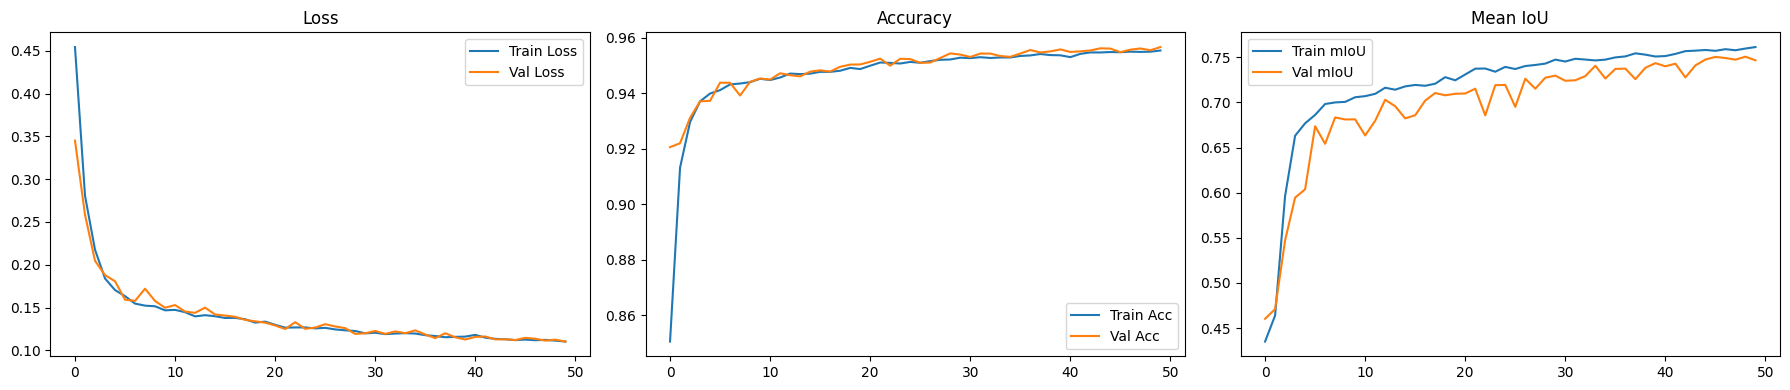

In [18]:
num_epochs = 50
learning_rate = 1e-3
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

train_history = {'loss': [], 'acc': [], 'miou': []}
val_history = {'loss': [], 'acc': [], 'miou': []}
best_miou = 0.0
best_state = None

for epoch in range(1, num_epochs + 1):
    tr_loss, tr_acc, tr_miou = train_one_epoch(model, train_loader, optimizer, criterion, device, num_classes=num_classes)
    val_loss, val_acc, val_miou = evaluate_model(model, val_loader, criterion, device, num_classes=num_classes)

    train_history['loss'].append(tr_loss)
    train_history['acc'].append(tr_acc)
    train_history['miou'].append(tr_miou)

    val_history['loss'].append(val_loss)
    val_history['acc'].append(val_acc)
    val_history['miou'].append(val_miou)

    if val_miou > best_miou:
        best_miou = val_miou
        best_state = model.state_dict()
    print(f"Epoch [{epoch}/{num_epochs}] - Train Loss: {tr_loss:.4f}, Val Loss: {val_loss:.4f}, Val mIoU: {val_miou:.4f}")

if best_state is not None:
    model.load_state_dict(best_state)

# Plot training curves
fig, axs = plt.subplots(1, 3, figsize=(18, 4))
axs[0].plot(train_history['loss'], label='Train Loss')
axs[0].plot(val_history['loss'], label='Val Loss')
axs[0].set_title('Loss')
axs[0].legend()

axs[1].plot(train_history['acc'], label='Train Acc')
axs[1].plot(val_history['acc'], label='Val Acc')
axs[1].set_title('Accuracy')
axs[1].legend()

axs[2].plot(train_history['miou'], label='Train mIoU')
axs[2].plot(val_history['miou'], label='Val mIoU')
axs[2].set_title('Mean IoU')
axs[2].legend()
plt.tight_layout()
plt.show()



In [ ]:
model.eval()
test_loss, test_acc, test_miou = evaluate_model(model, test_loader, criterion, device, num_classes=num_classes)
print(f"Final Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}, Test mIoU: {test_miou * 100:.2f}%")



Final Test Loss: 0.1175, Test Accuracy: 0.9558, Test mIoU: 74.91%


<h2 style = "color: green;">5. Inference [10 Points]</h2>

**Plot a few samples with the test image, predicted mask and the predicted mask overlayed onto the retinal eye image.**




In [20]:
def predict_and_visualize(model, dataset, num_samples: int = 3):
    model.eval()
    samples = min(num_samples, len(dataset))
    plt.figure(figsize=(14, 4 * samples))
    for i in range(samples):
        image, mask = dataset[i]
        sample_path = dataset.samples[i][0] if hasattr(dataset, 'samples') else None
        sample_name = Path(sample_path).name if sample_path is not None else f'sample_{i}'
        sample_folder = Path(sample_path).parent.name if sample_path is not None else 'unknown_folder'
        with torch.no_grad():
            logits = model(image.unsqueeze(0).to(device))
            pred_mask = logits.argmax(dim=1).squeeze(0).cpu()
        overlay_pred = overlay_mask_on_image(image, pred_mask)

        plt.subplot(samples, 3, i * 3 + 1)
        plt.imshow(image.permute(1, 2, 0))
        plt.title(f"Input Image\n{sample_name} @ {sample_folder}")
        plt.axis('off')

        plt.subplot(samples, 3, i * 3 + 2)
        plt.imshow(pred_mask, cmap='gray')
        plt.title('Predicted Mask')
        plt.axis('off')

        plt.subplot(samples, 3, i * 3 + 3)
        plt.imshow(overlay_pred)
        plt.title('Overlay')
        plt.axis('off')
    plt.tight_layout()
    plt.show()




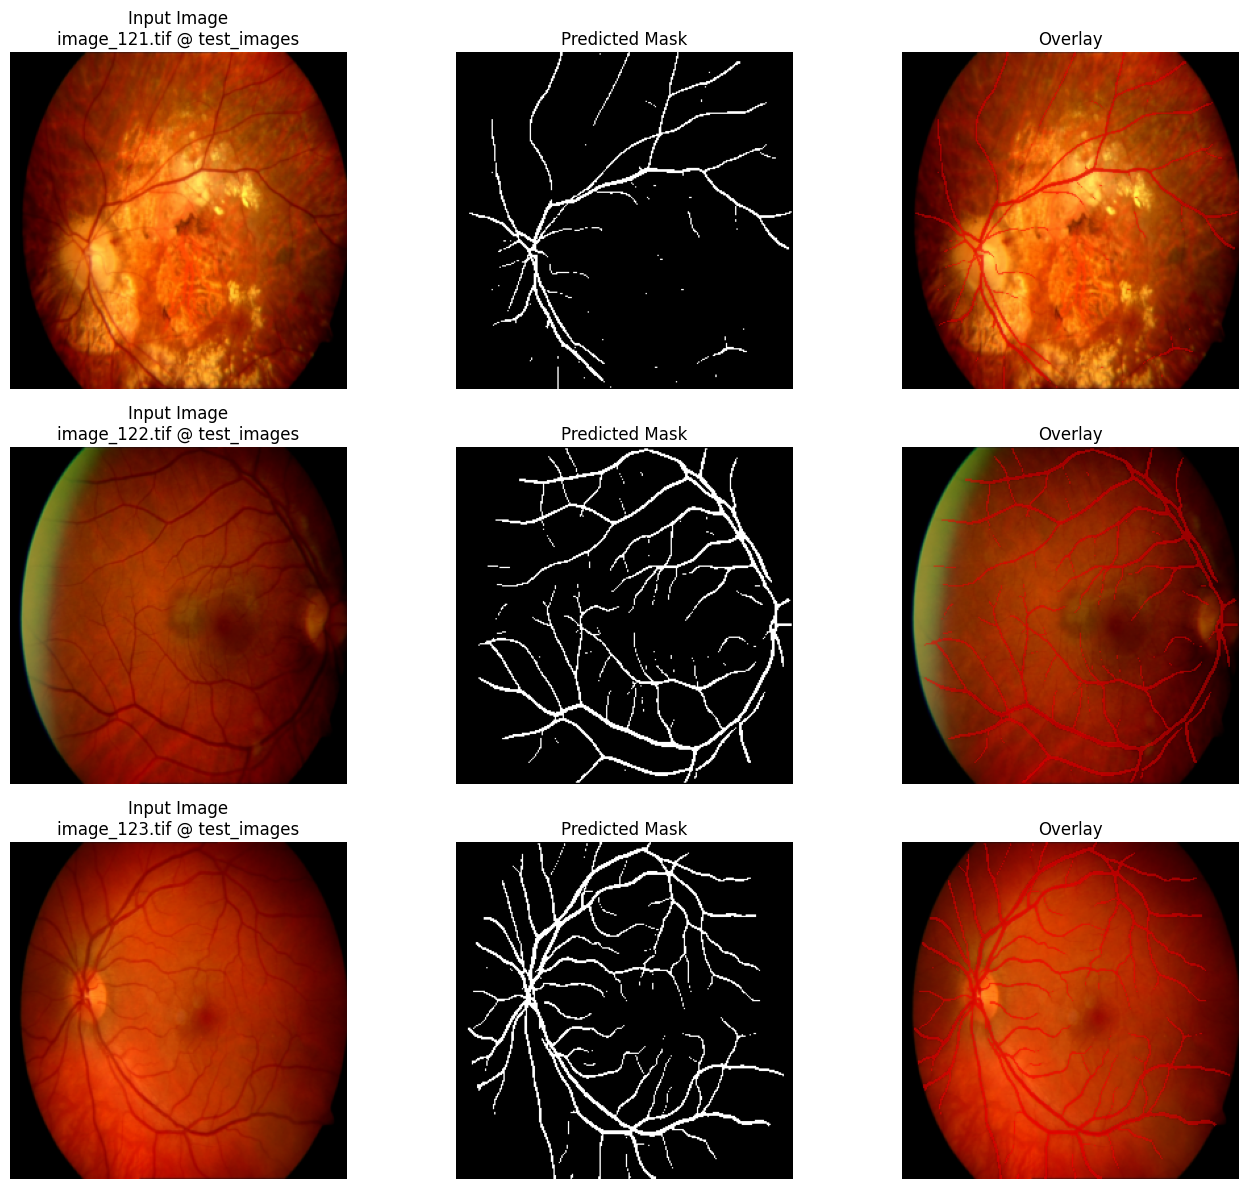

In [21]:
predict_and_visualize(model, test_dataset if len(test_dataset) > 0 else val_dataset, num_samples=3)



In [22]:
model.eval()
all_conf = torch.zeros((num_classes, num_classes), dtype=torch.float64, device=device)
with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)
        logits = model(images)
        preds = logits.argmax(dim=1)
        all_conf += compute_confusion_matrix(preds, masks, num_classes=num_classes)

final_iou = compute_iou_per_class(all_conf).cpu().numpy()
final_miou = final_iou.mean()
print('Per-class IoU:', final_iou)
print(f'Final Test mIoU: {final_miou * 100:.2f}%')



Per-class IoU: [0.9531381 0.5654977]
Final Test mIoU: 75.93%
